In [2]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments

import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns


In [1]:
import datasets

C:\Users\Bikram\anaconda3\envs\earning_call-ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import accelerate

In [4]:
from accelerate import Accelerator

In [5]:
from transformers.trainer import Trainer


In [6]:
from transformers import Trainer

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("GPU name:", torch.cuda.get_device_name(0) if device == "cuda" else "N/A")

Device: cuda
GPU name: NVIDIA GeForce RTX 2050


In [8]:
data_path = Path("../data/evasion_labels_usefullPair.json")

with open(data_path, encoding="utf-8") as f:
    samples = json.load(f)

print("Total samples:", len(samples))

label_counts = {}
for s in samples:
    label_counts[s["label"]] = label_counts.get(s["label"], 0) + 1

print(label_counts)

Total samples: 8853
{'DIRECT': 4636, 'EVASIVE': 4217}


In [11]:
LABEL2ID = {"DIRECT": 0, "EVASIVE": 1}
ID2LABEL = {0: "DIRECT", 1: "EVASIVE"}

texts  = []
labels = []

for s in samples:
    q = s["question"][:400]
    a = s["answer"][:600]
    # DeBERTa cross-encoder uses [CLS] text_a [SEP] text_b [SEP] format
    # We pass question and answer as separate segments, not concatenated string
    texts.append((q, a))
    labels.append(LABEL2ID[s["label"]])

print("Total texts:", len(texts))
print()
print("Sample:")
print("Q:", texts[0][0][:100])
print("A:", texts[0][1][:100])
print("Label:", labels[0])

Total texts: 8853

Sample:
Q: So Tim, and maybe this is for Luca as well. You talked about the supply chain returning back to norm
A: This is Tim, David. From a supply point of view, we did see disruption from early November through m
Label: 0


In [13]:
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))

Train: 7082 Val: 885 Test: 886


In [14]:
class EvasionDataset(Dataset):
    def __init__(self, samples, labels, tokenizer, max_length=512):
        questions = [s[0] for s in samples]
        answers   = [s[1] for s in samples]

        self.encodings = tokenizer(
            questions,
            answers,
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt"
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "token_type_ids": self.encodings["token_type_ids"][idx],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [15]:
BASE_MODEL = "cross-encoder/nli-deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

train_ds = EvasionDataset(X_train, y_train, tokenizer)
val_ds   = EvasionDataset(X_val,   y_val,   tokenizer)
test_ds  = EvasionDataset(X_test,  y_test,  tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
)

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2382.62it/s]
[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-base
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_evasive": f1_score(labels, preds, average="binary", pos_label=1),
        "f1_macro":   f1_score(labels, preds, average="macro"),
        "accuracy":   float((preds == labels).mean())
    }

training_args = TrainingArguments(
    output_dir = "evasion/checkpoints",
    num_train_epochs = 6,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    learning_rate = 1e-5,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "f1_evasive",
    greater_is_better = True,
    logging_steps = 20,
    fp16 = (device == "cuda"),
    seed = 42,
    report_to = "none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
from transformers import EarlyStoppingCallback

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

trainer.train()

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [17]:
preds_output = trainer.predict(test_ds)
y_pred = np.argmax(preds_output.predictions, axis=-1)

f1_evasive = f1_score(y_test, y_pred, average="binary", pos_label=1)
print("Test EVASIVE F1:", f1_evasive)
print()
print(classification_report(y_test, y_pred, target_names=["DIRECT", "EVASIVE"]))

Test EVASIVE F1: 0.7043580683156655

              precision    recall  f1-score   support

      DIRECT       0.73      0.72      0.73       464
     EVASIVE       0.70      0.71      0.70       422

    accuracy                           0.72       886
   macro avg       0.72      0.72      0.72       886
weighted avg       0.72      0.72      0.72       886



In [ ]:
final_path = "evasion/final"

trainer.save_model(final_path)
tokenizer.save_pretrained(final_path)

metrics = {
    "f1_evasive": f1_evasive,
    "base_model": BASE_MODEL,
    "dataset": "evasion_labels_usefullPair.json",
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "note": "Plateaued around 0.71 F1 despite 2.6x data increase"
}

with open("evasion/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Model saved to:", final_path)
print("Metrics saved to: evasion/metrics.json")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]

Model saved to: evasion/final
Metrics saved to: evasion/metrics.json


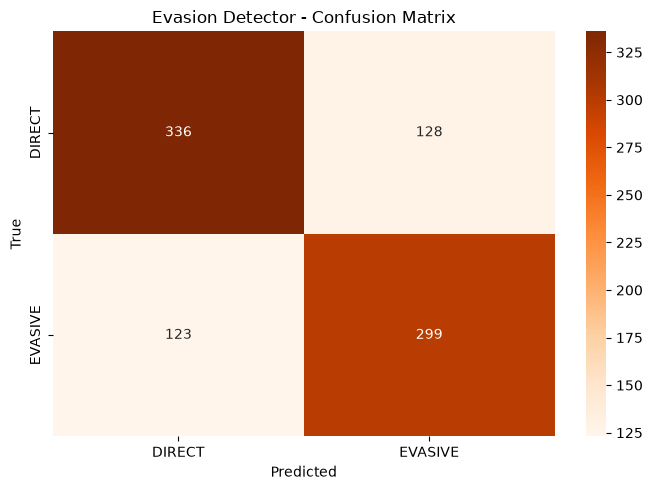

In [18]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=["DIRECT", "EVASIVE"], yticklabels=["DIRECT", "EVASIVE"])
plt.title("Evasion Detector - Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
# plt.savefig("evasion/confusion_matrix.png", dpi=150)
plt.show()